# V768 - Measuring Vision with Psychophysics

## Lab 8 - Motion Adaptation

In this lab, we will use a technique called top-up adaptation to measure the perceptual effects of motion adaptation.

### Learning Outcomes

(i.e., what you will be able to do at the end of this lab)

- Build a simple experiment using PsychoPy.

- Explain the impact of motion adaptation on the perception of motion direction in a motion direction discrimination task.

### Questions

- Explain what top-up adaptation is.

- Include and write a caption for the LAST figure in Part A, Step 3 (Analyze the data).

- Include and write a caption for the LAST figure in Part B, Step 3 (Analyze the data).

- Compare the results from both experiments. What is similar? What is different? If there are differences, explain what caused them.

## Part A. Simple Motion Coherence Experiment

### Step 1. Data collection

To collect data, open the PsychoPy ".psyexp" file in the folder titled "motion-simple-example", and run that experiment. The instructions will appear on the screen before the trials begin. A single run of the experiment includes 140 trials.

### Step 2. Load your data

#### Find files for specific participant ID

Before running this section of code, enter the participant ID you used below.


In [1]:
from pathlib import Path
from statistics import NormalDist
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import psignifit as ps
except ImportError:
    ps = None

rng = np.random.default_rng(2025)


def normcdf(x, mu, sigma):
    x = np.asarray(x, dtype=float)
    sigma = max(float(sigma), np.finfo(float).eps)
    dist = NormalDist(float(mu), sigma)
    return np.vectorize(dist.cdf, otypes=[float])(x)


def norminv(p, mu, sigma):
    p = np.asarray(p, dtype=float)
    p = np.clip(p, np.finfo(float).eps, 1 - np.finfo(float).eps)
    sigma = max(float(sigma), np.finfo(float).eps)
    dist = NormalDist(float(mu), sigma)
    return np.vectorize(dist.inv_cdf, otypes=[float])(p)


def psyfxn(c, x):
    c = np.asarray(c, dtype=float)
    return (normcdf(x, c[0], c[1]) * (1 - c[2] - c[3])) + c[2]


def ipsyfxn(c, p):
    c = np.asarray(c, dtype=float)
    return norminv((np.asarray(p, dtype=float) - c[2]) / (1 - c[2] - c[3]), c[0], c[1])


def fit_psignifit(data, experiment_type="yes/no"):
    if ps is None:
        raise ImportError("psignifit is required for psychometric fitting. Install it with: pip install psignifit")
    try:
        return ps.psignifit(data, experiment_type=experiment_type, sigmoid="norm")
    except TypeError:
        exp_type = "YesNo" if experiment_type.lower() in {"yes/no", "yesno", "yes-no"} else experiment_type
        options = {"expType": exp_type, "sigmoidName": "norm"}
        return ps.psignifit(data, options)


def psignifit_parameter_array(result, fallback_gamma=0.0, fallback_lambda=0.0):
    if hasattr(result, "parameter_estimate"):
        params = result.parameter_estimate
        try:
            mu, sigma = result.standard_parameter_estimate()
        except Exception:
            mu = params.get("threshold", np.nan)
            sigma = params.get("width", np.nan)
        return np.array([
            mu,
            sigma,
            params.get("gamma", fallback_gamma),
            params.get("lambda", fallback_lambda),
        ], dtype=float)

    if isinstance(result, dict):
        fit = np.asarray(result["Fit"], dtype=float)
        # psignifit 4 order is commonly [threshold, width, lambda, gamma, eta].
        return np.array([
            fit[0],
            fit[1],
            fit[3] if fit.size > 3 else fallback_gamma,
            fit[2] if fit.size > 2 else fallback_lambda,
        ], dtype=float)

    raise TypeError("Could not read fitted parameters from this psignifit result object.")


def psignifit_predict(result, x, params=None):
    x = np.asarray(x, dtype=float)
    if hasattr(result, "proportion_correct"):
        return np.asarray(result.proportion_correct(x), dtype=float)
    if params is None:
        params = psignifit_parameter_array(result)
    return psyfxn(params, x)


def find_participant_files(data_dir, participant_id):
    data_dir = Path(data_dir)
    if not data_dir.exists():
        raise FileNotFoundError(
            "PsychoPy data folder not found. Try changing your current Python "
            "folder to the folder containing this notebook."
        )
    file_paths = sorted(path for path in data_dir.glob(f"{participant_id}*.csv") if path.name.startswith(participant_id))
    if not file_paths:
        raise FileNotFoundError("No files found.")
    file_info = pd.DataFrame({
        "name": [path.name for path in file_paths],
        "folder": [str(path.parent) for path in file_paths],
        "path": file_paths,
    })
    print("data files found:")
    for name in file_info["name"]:
        print(f'    "{name}"')
    return file_info


def load_psychopy_csvs(file_info, remove_instruction_rows=True):
    frames = []
    for path in file_info["path"]:
        this_data = pd.read_csv(path)
        if remove_instruction_rows:
            if "thisN" in this_data.columns:
                this_data = this_data[this_data["thisN"].notna()]
            elif "trials.thisN" in this_data.columns:
                this_data = this_data[this_data["trials.thisN"].notna()]
            else:
                this_data = this_data.iloc[1:]
        frames.append(this_data.reset_index(drop=True))
    data = pd.concat(frames, ignore_index=True)
    data = data.drop(columns=["notes", "begin_experiment.started", "begin_experiment.stopped"], errors="ignore")
    return data


def display_fit_table(params, columns=("fit",)):
    return pd.DataFrame(
        np.asarray(params).reshape(4, -1),
        index=["mu", "sigma", "gamma", "lambda"],
        columns=list(columns),
    )
participant_id = "demo"

# check current working directory and find files
file_info = find_participant_files(Path("motion-simple-example") / "data", participant_id)
n_files = len(file_info)


data files found:
    "demo_motion-simple-example_2025-03-04_22h13.50.730.csv"


**Confirm that your data file is listed above.** There should be one file.

#### Load and merge data tables


In [2]:
# load data and stack it into one table
expt_data = load_psychopy_csvs(file_info)

# display data table size
n_trials = len(expt_data)
print(f"number of trials = {n_trials}")


number of trials = 140


### Step 3. Analyze your data

For this experiment, the stimulus was a field of dots. Both direction of motion and motion coherence varied. The coherence defines the proportion of dots that move in the direction of motion. The direction of motion was either to the right (0 degrees) or to the left (180 degrees), and the task was to report whether the motion was rightward or leftward.

For each trial, PsychoPy saved the motion direction, the motion coherence, and the participant's response. The responses were stored as 'left' or 'right'.


In [3]:
# stash the stimulus location and response data
motion_coherence = expt_data["coherence"].astype(float)
motion_direction = expt_data["direction"].astype(float).copy()
resp_key = expt_data["key_resp.keys"].astype(str)

# convert stimulus motion direction to 1 for right and -1 for left
motion_direction = motion_direction.replace({180: -1, 0: 1})

# calculate signed motion coherence
signed_motion_coherence = motion_coherence * motion_direction

# convert the response key to 1 for right and -1 for left
# (to match stimulus direction)
resp_direction = np.where(resp_key.eq("right"), 1, -1)


#### Determine whether responses were correct or incorrect

For a response to be correct, the stimulus motion and response directions must match.


In [4]:
# determine whether responses were correct or incorrect
resp_correct = motion_direction.to_numpy() == resp_direction

# determine whether participant chose right
chose_right = resp_direction == 1

# display overall performance
print(f"overall percentage correct = {np.mean(resp_correct) * 100:.2f}%")


overall percentage correct = 83.57%


#### Determine performance per condition

We need to now separate responses by stimulus condition to visualize performance in a psychometric curve. To accomplish that, we can separate by the signed motion coherence values that we calculated above. (Positive values indicate rightward motion, and negative values indicate leftward motion.)


In [5]:
# average across responses per contrast level
analysis_table = pd.DataFrame({"response": chose_right, "coherence": signed_motion_coherence})
expt_results = (
    analysis_table
    .groupby("coherence", as_index=False)
    .agg(n_trials=("response", "size"), prob_right=("response", "mean"))
)

# stash stimulus levels & counts
coherence_levels = np.sort(expt_results["coherence"].unique())
n_coherence = len(coherence_levels)

# display results
display(expt_results)


,coherence,n_trials,prob_right
0,-1.0,10,0.00
1,-0.5,10,0.00
2,-0.4,10,0.00
3,-0.3,10,0.00
4,-0.2,10,0.10
5,-0.1,10,0.20
6,-0.0,20,0.45
7,0.1,10,0.70
8,0.2,10,0.90
9,0.3,10,0.90


#### Plot performance per condition


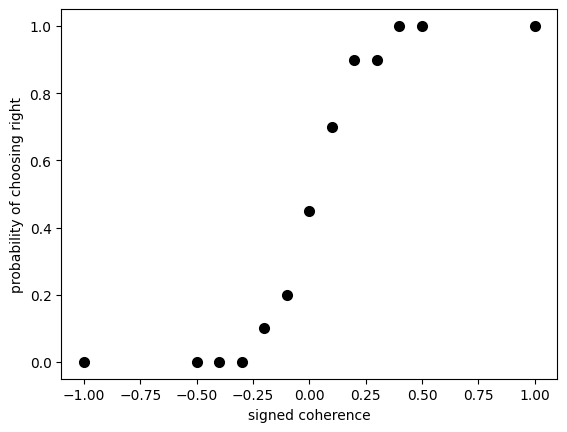

In [6]:
fig, ax = plt.subplots()
ax.scatter(expt_results["coherence"], expt_results["prob_right"], color='k', linewidth=2)
ax.set_xlabel("signed coherence")
ax.set_ylabel("probability of choosing right")
plt.show()


#### **Fit data.**


In [7]:
# fit psychometric curve to data using psignifit
expt_psignifit_data = np.column_stack([
    expt_results["coherence"].to_numpy(dtype=float),
    expt_results["prob_right"].to_numpy(dtype=float) * expt_results["n_trials"].to_numpy(dtype=float),
    expt_results["n_trials"].to_numpy(dtype=float),
])
expt_psignifit_result = fit_psignifit(expt_psignifit_data, experiment_type="yes/no")
expt_params = psignifit_parameter_array(expt_psignifit_result, fallback_gamma=0.0, fallback_lambda=0.0)
discrim_param_table = display_fit_table(expt_params)
display(discrim_param_table)


,fit
mu,2.552372e-02
sigma,1.576424e-01
gamma,1.341345e-09
lambda,1.131864e-08


#### Plot fit with data.


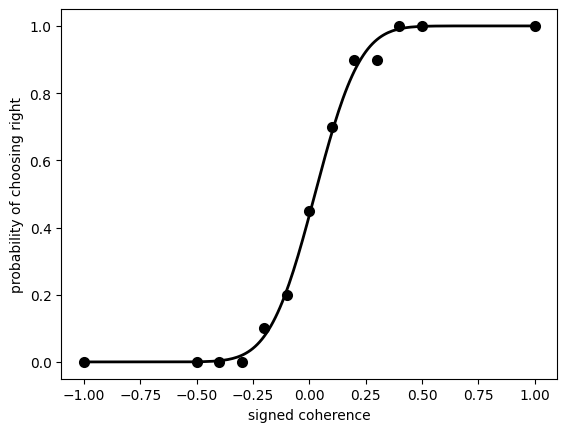

In [8]:
fig, ax = plt.subplots()
xx = np.arange(-1, 1.01, 0.01)
yy = psignifit_predict(expt_psignifit_result, xx, expt_params)
ax.scatter(expt_results["coherence"], expt_results["prob_right"], color='k', linewidth=2)
ax.plot(xx, yy, 'k-', linewidth=2)
ax.set_xlabel("signed coherence")
ax.set_ylabel("probability of choosing right")
plt.show()


#### Calculate and plot both PSE and JND


0.02552371846244682
0.11147004431364257


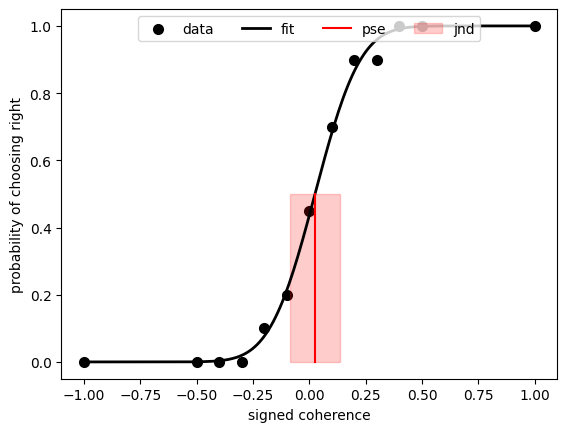

In [9]:
# calculate PSE
pse = float(ipsyfxn(expt_params, 0.5))
print(pse)

# calculate JND
jnd = float(expt_params[1] / np.sqrt(2))
print(jnd)

# plot the PSE +/- JND along with the data and fitted curve
fig, ax = plt.subplots()
ax.scatter(expt_results["coherence"], expt_results["prob_right"], color='k', linewidth=2, label='data')
ax.plot(xx, yy, 'k-', linewidth=2, label='fit')
ax.plot([pse, pse], [0, 0.5], 'r-', linewidth=1.5, label='pse')
jnd_x = np.array([pse - jnd, pse + jnd, pse + jnd, pse - jnd])
jnd_y = np.array([0, 0, 0.5, 0.5])
ax.fill(jnd_x, jnd_y, color='r', alpha=0.2, label='jnd')
ax.set_xlabel("signed coherence")
ax.set_ylabel("probability of choosing right")
ax.legend(loc='upper center', ncol=4)
plt.show()


**What do you see?** What do you expect to happen to this curve if you perform the experiment while being adapted to motion to the right?  What about to the left?

## Part B. Motion Adaptation Experiment

### Step 1. Data collection

To collect data, open the PsychoPy ".psyexp" file in the folder titled "motion-adaptation", and run that experiment. The instructions will appear on the screen before the trials begin. A single run of the experiment includes 140 trials.

### Step 2. Load your data

#### Find files for specific participant ID

Before running this section of code, enter the participant ID you used below.


In [10]:
participant_id = "demo"

# check current working directory and find files
file_info = find_participant_files(Path("motion-adaptation") / "data", participant_id)
n_files = len(file_info)


data files found:
    "demo_motion-adaptation_2025-03-05_19h44.16.495.csv"


**Confirm that your data file is listed above.** There should be one file.


In [11]:
# load data and stack it into one table
adapt_data = load_psychopy_csvs(file_info, remove_instruction_rows=False)
adapt_data = adapt_data[adapt_data["coherence"].notna()].reset_index(drop=True)

# display data table size
n_trials = len(adapt_data)
print(f"number of trials = {n_trials}")


number of trials = 140


### Step 3. Analyze your data

For this experiment, the stimulus was a field of dots. Both direction of motion and motion coherence varied. The coherence defines the proportion of dots that move in the direction of motion. The direction of motion was either to the right (0 degrees) or to the left (180 degrees), and the task was to report whether the motion was rightward or leftward.

For each trial, PsychoPy saved the motion direction, the motion coherence, and the participant's response. The responses were stored as 'left' or 'right'.


In [12]:
# stash the stimulus location and response data
motion_coherence = adapt_data["coherence"].astype(float)
motion_direction = adapt_data["direction"].astype(float).copy()
resp_key = adapt_data["key_resp.keys"].astype(str)

# convert stimulus motion direction to 1 for right and -1 for left
motion_direction = motion_direction.replace({180: -1, 0: 1})

# create signed motion coherence
signed_motion_coherence = motion_coherence * motion_direction

# convert the response key to 1 for right and -1 for left
# (to match stimulus location)
resp_direction = np.where(resp_key.eq("right"), 1, -1)


#### Determine whether responses were correct or incorrect

For a response to be correct, the motion direction must match the response direction.


In [13]:
# determine whether responses were correct or incorrect
resp_correct = motion_direction.to_numpy() == resp_direction

chose_right = resp_direction == 1

# display overall performance
print(f"overall percentage correct = {np.mean(resp_correct) * 100:.2f}%")


overall percentage correct = 80.71%


#### Determine performance per condition

We need to now separate by coherence and direction to visualize performance in a psychometric curve.


In [14]:
# average across responses per contrast level
analysis_table = pd.DataFrame({"response": chose_right, "coherence": signed_motion_coherence})
adapt_results = (
    analysis_table
    .groupby("coherence", as_index=False)
    .agg(n_trials=("response", "size"), prob_right=("response", "mean"))
)

# stash stimulus levels & counts
coherence_levels = np.sort(adapt_results["coherence"].unique())
n_coherence = len(coherence_levels)

# display results
display(adapt_results)


,coherence,n_trials,prob_right
0,-1.0,10,0.00
1,-0.5,10,0.00
2,-0.4,10,0.00
3,-0.3,10,0.00
4,-0.2,10,0.10
5,-0.1,10,0.20
6,0.0,20,0.05
7,0.1,10,0.60
8,0.2,10,0.50
9,0.3,10,0.80


#### Plot performance per condition


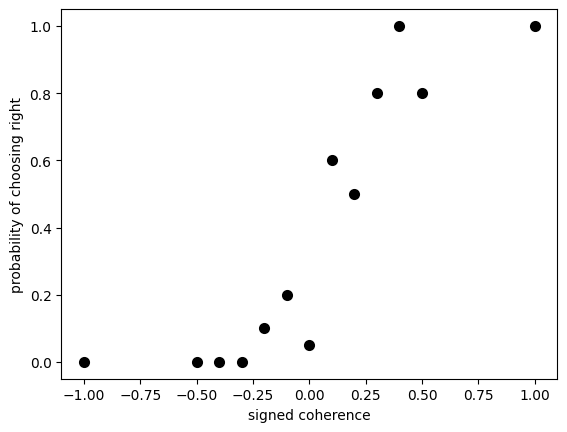

In [15]:
fig, ax = plt.subplots()
ax.scatter(adapt_results["coherence"], adapt_results["prob_right"], color='k', linewidth=2)
ax.set_xlabel("signed coherence")
ax.set_ylabel("probability of choosing right")
plt.show()


#### **Fit data**


In [16]:
# fit psychometric curve to data using psignifit
adapt_psignifit_data = np.column_stack([
    adapt_results["coherence"].to_numpy(dtype=float),
    adapt_results["prob_right"].to_numpy(dtype=float) * adapt_results["n_trials"].to_numpy(dtype=float),
    adapt_results["n_trials"].to_numpy(dtype=float),
])
adapt_psignifit_result = fit_psignifit(adapt_psignifit_data, experiment_type="yes/no")
adapt_params = psignifit_parameter_array(adapt_psignifit_result, fallback_gamma=0.0, fallback_lambda=0.0)
adapt_param_table = display_fit_table(adapt_params)
display(adapt_param_table)


,fit
mu,1.672429e-01
sigma,2.191232e-01
gamma,8.217078e-07
lambda,3.810918e-06


#### Plot fit with data


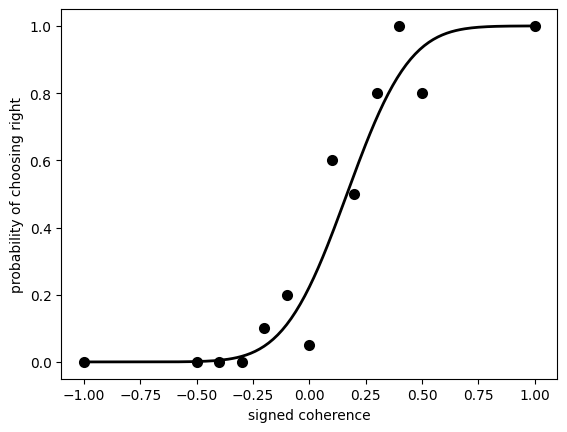

In [17]:
fig, ax = plt.subplots()
xx = np.arange(-1, 1.01, 0.01)
yy = psignifit_predict(adapt_psignifit_result, xx, adapt_params)
ax.scatter(adapt_results["coherence"], adapt_results["prob_right"], color='k', linewidth=2)
ax.plot(xx, yy, 'k-', linewidth=2)
ax.set_xlabel("signed coherence")
ax.set_ylabel("probability of choosing right")
plt.show()


#### Calculate and plot both PSE and JND


0.16724375241621856
0.15494350706364868


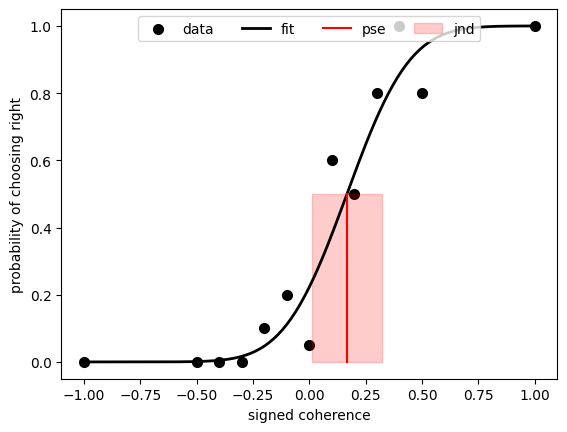

In [18]:
# calculate PSE
pse = float(ipsyfxn(adapt_params, 0.5))
print(pse)

# calculate JND
jnd = float(adapt_params[1] / np.sqrt(2))
print(jnd)

# plot the PSE +/- JND along with the data and fitted curve
fig, ax = plt.subplots()
ax.scatter(adapt_results["coherence"], adapt_results["prob_right"], color='k', linewidth=2, label='data')
ax.plot(xx, yy, 'k-', linewidth=2, label='fit')
ax.plot([pse, pse], [0, 0.5], 'r-', linewidth=1.5, label='pse')
jnd_x = np.array([pse - jnd, pse + jnd, pse + jnd, pse - jnd])
jnd_y = np.array([0, 0, 0.5, 0.5])
ax.fill(jnd_x, jnd_y, color='r', alpha=0.2, label='jnd')
ax.set_xlabel("signed coherence")
ax.set_ylabel("probability of choosing right")
ax.legend(loc='upper center', ncol=4)
plt.show()
